# Capstone Project Exploratory Data Analysis Notebook:
**Authors: Nick Sarka, Alex Hamill, Nick Goshev, Matt Johnescu, Carson Hansen**

# Table of Contents:
- [Introduction](#introduction)
- [Business Problem Statement](#busines-problem-statement)
- [Description of the data](#Description-of-the-data)
- [Discussion of missing data](#Discussion-of-missing-data)
- [Exploratory Visualizations and/or Summary Tables](#Exploratory-Visualizations-and/or-Summary-Tables)
- [Results](#Results)

# Introduction
The purpose of this EDA notebook is to explore and analyze data related to unplanned maintenance events at Swire Coca-Cola's production plants. This analysis aims to identify patterns and key factors contributing to machine breakdowns, with a particular focus on understanding the frequency of failures, time between breakdowns, and the effectiveness of past maintenance activities.

By examining the relationships between variables such as EQUIPMENT_ID, ACTUAL_WORK_IN_MINUTES, and MAINTENANCE_ACTIVITY_TYPE, this notebook will lay the groundwork for developing a predictive model to prevent unplanned downtime. The insights gained here will help to guide feature selection and prepare the data for future modeling efforts to reduce costly production losses.

- Reducing downtime variable - Target

# Busines Problem Statement
Swire Coca-Cola has six production plants to meet the demand of 192 million cases of various beverages from 13 different states. These plants are currently only able to meet 94.4% of the demand. One of the reasons these plants fall short of meeting the total product demand is that they are plagued with unplanned downtime. This downtime is caused by various failure modes like maintenance, mechanical failure, general wear and tear, etc.

Extensive repairs result in lengthy downtimes that generate work orders in the IWC system.  The long lead times caused by these work orders cost Swire Coca-Cola $60 million annually in production losses.  

The purpose of this project is to create a predictive model to identify machines at risk of failure to prevent downtime and optimize Swire Coca-Cola's plant machine maintenance.

In [1]:
# Library importation
import pandas as pd
from google.colab import drive
from google.colab import auth
import os
!pip install GitPython
import git
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.6 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
master_df = pd.read_csv('/content/drive/My Drive/CocaColaSwire.csv')

<ipython-input-2-1e4768ce4f8b>:1: DtypeWarning: Columns (8,11,12,13,14,15,16,17,18,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  master_df = pd.read_csv('/content/drive/My Drive/CocaColaSwire.csv')


In [3]:
# GROUP 1: Matt, Alex, Carson
group_1_df = master_df.copy()

# GROUP 2: Nick S., Nick G.
group_2_df = master_df.copy()

# Description of the data

In [4]:
group_2_df.dtypes

,0
ORDER_ID,int64
PLANT_ID,object
PRODUCTION_LOCATION,object
EXECUTION_START_DATE,object
EXECUTION_FINISH_DATE,object
ACTUAL_START_TIME,object
ACTUAL_FINISH_TIME,object
ACTUAL_WORK_IN_MINUTES,float64
MAINTENANCE_PLAN,object
MAINTENANCE_ITEM,float64


In [5]:
group_2_df.shape

(1427264, 25)

In [6]:
for column in group_2_df.columns:
  print(f"Value counts for column '{column}':")
  print(group_2_df[column].value_counts())
  print("\n")

Value counts for column 'ORDER_ID':
ORDER_ID
301040694       2
207541573       2
207558009       2
207557881       2
207558253       2
               ..
200002062795    1
401432172       1
1000065639      1
200002617500    1
700801825       1
Name: count, Length: 1427244, dtype: int64


Value counts for column 'PLANT_ID':
PLANT_ID
G261    630903
G221    290975
G291    225279
G816    116303
G811     84694
G812     79110
Name: count, dtype: int64


Value counts for column 'PRODUCTION_LOCATION':
PRODUCTION_LOCATION
SILVERSTONE    630903
SUZUKA         290975
MONZA          225279
COTA           116303
MONACO          84694
ROMA            79110
Name: count, dtype: int64


Value counts for column 'EXECUTION_START_DATE':
EXECUTION_START_DATE
2019-04-16    936
2018-09-12    908
2018-08-08    900
2023-05-23    895
2019-01-23    892
             ... 
2024-08-30      4
2013-08-19      1
2021-12-25      1
2016-07-25      1
2016-07-28      1
Name: count, Length: 2956, dtype: int64


Value counts 

From the value counts we can quickly see that there appears to be a lot of missing data, with total value counts not seemingly matching up with the total shape of our dataframe (which will be explored later). However from the data we are given, it is very clear that some important columns stick out. Our hypothesis is that the columns **"PRODUCTION_LOCATION", "ACTUAL_WORK_IN_MINUTES", "MAINTENANCE_ITEM", "MAINTENANCE_ACTIVITY_TYPE", "MAINTENANCE_TYPE_DESCRIPTION", "FUNCTIONAL_LOC", "EQUIPMENT_ID", "EQUIPMENT_CAT_DESC"** are seemingly the most important before any analysis is done. These columns from our data description are seemingly the most important because they outline a strong categorical description of not only what is being maintenanced but also where it is being maintenanced and most importantly how long the work to get the machine working again has taken. Outside of this the data is largely categorical in nature with lots of date/time columns and other descriptive columns that are of object type.

# Discussion of missing data


### isnull check for each column in df

In [7]:
for column in group_2_df.columns:
  print(f"Column: {column}")
  print(group_2_df[column].isnull().sum())
  print("-" * 20)

Column: ORDER_ID
0
--------------------
Column: PLANT_ID
0
--------------------
Column: PRODUCTION_LOCATION
0
--------------------
Column: EXECUTION_START_DATE
0
--------------------
Column: EXECUTION_FINISH_DATE
0
--------------------
Column: ACTUAL_START_TIME
0
--------------------
Column: ACTUAL_FINISH_TIME
0
--------------------
Column: ACTUAL_WORK_IN_MINUTES
0
--------------------
Column: MAINTENANCE_PLAN
1274670
--------------------
Column: MAINTENANCE_ITEM
1274670
--------------------
Column: MAINTENANCE_ACTIVITY_TYPE
0
--------------------
Column: ORDER_DESCRIPTION
1135497
--------------------
Column: MAINTENANCE_TYPE_DESCRIPTION
1135469
--------------------
Column: FUNCTIONAL_LOC
1135482
--------------------
Column: FUNCTIONAL_AREA_NODE_1_MODIFIED
1137147
--------------------
Column: FUNCTIONAL_AREA_NODE_2_MODIFIED
1144857
--------------------
Column: FUNCTIONAL_AREA_NODE_3_MODIFIED
1168573
--------------------
Column: FUNCTIONAL_AREA_NODE_4_MODIFIED
1189691
------------------

### NULLS by Column

In [8]:
def null_percentage_col(df):
  """
  Calculates the percentage of null or NaN values in each column of a DataFrame.

  Args:
    df: The pandas DataFrame.

  Returns:
    A pandas Series containing the percentage of null values for each column.
  """
  return (df.isnull().sum() / len(df)) * 100

In [9]:
null_percentages_col2 = null_percentage_col(group_2_df)
print(null_percentages_col2)

ORDER_ID                            0.000000
PLANT_ID                            0.000000
PRODUCTION_LOCATION                 0.000000
EXECUTION_START_DATE                0.000000
EXECUTION_FINISH_DATE               0.000000
ACTUAL_START_TIME                   0.000000
ACTUAL_FINISH_TIME                  0.000000
ACTUAL_WORK_IN_MINUTES              0.000000
MAINTENANCE_PLAN                   89.308635
MAINTENANCE_ITEM                   89.308635
MAINTENANCE_ACTIVITY_TYPE           0.000000
ORDER_DESCRIPTION                  79.557601
MAINTENANCE_TYPE_DESCRIPTION       79.555639
FUNCTIONAL_LOC                     79.556550
FUNCTIONAL_AREA_NODE_1_MODIFIED    79.673207
FUNCTIONAL_AREA_NODE_2_MODIFIED    80.213401
FUNCTIONAL_AREA_NODE_3_MODIFIED    81.875042
FUNCTIONAL_AREA_NODE_4_MODIFIED    83.354656
FUNCTIONAL_AREA_NODE_5_MODIFIED    99.847260
EQUIPMENT_ID                       79.555639
EQUIPMENT_DESC                     94.433616
EQUIP_CAT_DESC                     94.433616
EQUIP_STAR

### NULLS by Row

In [10]:
def null_percentage_row(df):
  """
  Calculates the percentage of null or NaN values in each row of a DataFrame.

  Args:
    df: The pandas DataFrame.

  Returns:
    A pandas Series containing the percentage of null values for each row.
  """
  return (df.isnull().sum(axis=1) / df.shape[1]) * 100

In [11]:
null_percentage_row2 = null_percentage_row(group_2_df)
print(null_percentage_row2)

0           8.0
1           8.0
2           8.0
3           8.0
4          20.0
           ... 
1427259    24.0
1427260    24.0
1427261    24.0
1427262    32.0
1427263    24.0
Length: 1427264, dtype: float64


### Maintenance Activity Analysis

In [12]:
group_2_df['MAINTENANCE_ACTIVITY_TYPE'].value_counts()

,count
MAINTENANCE_ACTIVITY_TYPE,
Unplanned,1276877
Planned,150387


In [13]:
group_2_df[group_2_df['MAINTENANCE_ACTIVITY_TYPE'] == "Planned"].isnull().sum()/len(group_2_df)

,0
ORDER_ID,0.000000
PLANT_ID,0.000000
PRODUCTION_LOCATION,0.000000
EXECUTION_START_DATE,0.000000
EXECUTION_FINISH_DATE,0.000000
ACTUAL_START_TIME,0.000000
ACTUAL_FINISH_TIME,0.000000
ACTUAL_WORK_IN_MINUTES,0.000000
MAINTENANCE_PLAN,0.000000
MAINTENANCE_ITEM,0.000000


In [14]:
group_2_df[group_2_df['MAINTENANCE_ACTIVITY_TYPE'] == "Unplanned"].isnull().sum()/len(group_2_df)

,0
ORDER_ID,0.000000
PLANT_ID,0.000000
PRODUCTION_LOCATION,0.000000
EXECUTION_START_DATE,0.000000
EXECUTION_FINISH_DATE,0.000000
ACTUAL_START_TIME,0.000000
ACTUAL_FINISH_TIME,0.000000
ACTUAL_WORK_IN_MINUTES,0.000000
MAINTENANCE_PLAN,0.893086
MAINTENANCE_ITEM,0.893086


## Deciding which columns and rows to keep
Our goal when handling null values in this dataset is to preserve as much of the predictive power as possible. In this case we are concerned with predicting when are where the context of different breaks and downtimes occurs and as such we should keep columns with large proportions of null values such as FUNCTIONAL_LOC and EQUIPMENT_ID. What is concerning upon examining the data is that all columns that give context pre-maintenence have very large amounts of missing values. As we have discussed above preserving these columns is crucial so rather than remove columns we intend to remove the rows that do not provide data that can provide predictive power. We have also noticed that only the unplanned maintence rows have this extreme amount of missing values, as it is hard to deduce what happened in these entries we plan to drop the rows where MAINTENENCE_ACTIVITY_TYPE is "unplanned" and where the crucial columns we list are all null.

The following is a list of columns we have decided are necessary to provide sufficient information as well as the reasons for dropping others:

**ORDER_ID**  - this column is droppable as it serves as a unique identifier

**PLANT_ID** - This is the numerical identifier for PRODUCTION_LOCATION, we will be dropping this to prevent perfect multicollinearity

**PRODUCTION_LOCATION** - We are keepinng this feature over PLANT_ID for ease of interpretation

**EXECUTION_START_DATE** - This column is kept as it provides information on maintenence duration

**EXECUTION_FINISH_DATE** - This column is kept as it provides information on maintenence duration

ACTUAL_START_TIME - This column is kept as it provides information on maintenence duration

**ACTUAL_FINISH_TIME** - This column is kept as it provides information on maintenence duration

**ACTUAL_WORK_IN_MINUTES** - This column is dropped since it redundant and can be calculated by ACTUAL_FINISH_TIME - ACTUAL_START_TIME

**MAINTENANCE_PLAN** - Despite only being present for planned maintenence this column is kept to compare downtime durations between planned maintenence

**MAINTENANCE_ITEM** - Despite only being present for planned maintenence this column is kept to compare downtime durations between planned maintenence

**MAINTENANCE_ACTIVITY_TYPE** - This feature is kept as it is one of our targets

**ORDER_DESCRIPTION** - This feature is kept as it provides additional context on the maintenence

**MAINTENANCE_TYPE_DESCRIPTION** - This feature is kept as it provides additional context on the maintenence

**FUNCTIONAL_LOC** - We are keeping this feature and not the following 5 as the following 5 is just a granularization of this which contains all info

**FUNCTIONAL_AREA_NODE_1_MODIFIED** - information contained in FUNCTIONAL_LOC

**FUNCTIONAL_AREA_NODE_2_MODIFIED** - information contained in FUNCTIONAL_LOC

**FUNCTIONAL_AREA_NODE_3_MODIFIED** - information contained in FUNCTIONAL_LOC

**FUNCTIONAL_AREA_NODE_4_MODIFIED** - information contained in FUNCTIONAL_LOC

**FUNCTIONAL_AREA_NODE_5_MODIFIED** - information contained in FUNCTIONAL_LOC

**EQUIPMENT_ID** - Kept as this provides information on what was needed maintenence

**EQUIPMENT_DESC** - Kept as this provides information on what was needed maintenence

**EQUIP_CAT_DESC** - TBD

**EQUIP_START_UP_DATE** - TBD

EQUIP_VALID_TO - TBD

Notably some null values here represent a miniscule equipment piece, rather than null data. Our strategy for removing rows will be removing rows that do not contain values for ORDER_DESCRIPTION and MAINTENANCE_TYPE_DESCRIPTION and FUNCTIONAL_LOC and EQUIPMENT_ID as those are crucial columns that also have very similar rates of missing data which we believe are correlated to the missing data in the "unplanned" rows. In simpler terms from our observations if a row is missing one of these it is typically missing the others as well.



In [15]:

#IMPORTANT
# REPLACE DF PLACEHOLDER
df_col_drop=group_2_df.drop(['ORDER_ID','PLANT_ID','ACTUAL_WORK_IN_MINUTES'],axis=1)
#how to handle nodes? Equip start/vaid date?

df_filtered = df_col_drop.dropna(subset=['ORDER_DESCRIPTION', 'MAINTENANCE_TYPE_DESCRIPTION', 'FUNCTIONAL_LOC', 'EQUIPMENT_ID'], how='all')

df_filtered.isnull().sum()/len(df_filtered)


,0
PRODUCTION_LOCATION,0.000000
EXECUTION_START_DATE,0.000000
EXECUTION_FINISH_DATE,0.000000
ACTUAL_START_TIME,0.000000
ACTUAL_FINISH_TIME,0.000000
MAINTENANCE_PLAN,0.477051
MAINTENANCE_ITEM,0.477051
MAINTENANCE_ACTIVITY_TYPE,0.000000
ORDER_DESCRIPTION,0.000096
MAINTENANCE_TYPE_DESCRIPTION,0.000000


# Exploratory Visualizations and/or Summary Tables

### Non-Null Data by Functional Area

In [16]:
group_1_df[['FUNCTIONAL_LOC','FUNCTIONAL_AREA_NODE_1_MODIFIED','FUNCTIONAL_AREA_NODE_2_MODIFIED','FUNCTIONAL_AREA_NODE_3_MODIFIED','FUNCTIONAL_AREA_NODE_4_MODIFIED','FUNCTIONAL_AREA_NODE_5_MODIFIED']].count()

,0
FUNCTIONAL_LOC,291782
FUNCTIONAL_AREA_NODE_1_MODIFIED,290117
FUNCTIONAL_AREA_NODE_2_MODIFIED,282407
FUNCTIONAL_AREA_NODE_3_MODIFIED,258691
FUNCTIONAL_AREA_NODE_4_MODIFIED,237573
FUNCTIONAL_AREA_NODE_5_MODIFIED,2180


### Balance of Planned and Unplanned Variables

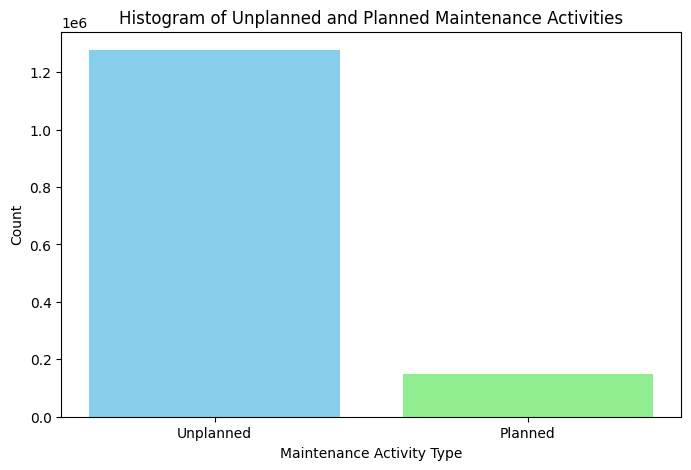

In [17]:
# Count the occurrences of 'UNPLANNED' and 'PLANNED' maintenance activities
maintenance_counts = group_1_df['MAINTENANCE_ACTIVITY_TYPE'].value_counts()

# Plotting the histogram
plt.figure(figsize=(8, 5))
plt.bar(maintenance_counts.index, maintenance_counts.values, color=['skyblue', 'lightgreen'])
plt.xlabel('Maintenance Activity Type')
plt.ylabel('Count')
plt.title('Histogram of Unplanned and Planned Maintenance Activities')
plt.show()


- There is a lot more Unplanned maintenance than Planned.
- This suggests and proves the problem of the project is present and UNPLANNED maintenance needs to be reduces

### 'FAILURE_COUNT' and 'PRODUCTION_LOCATION

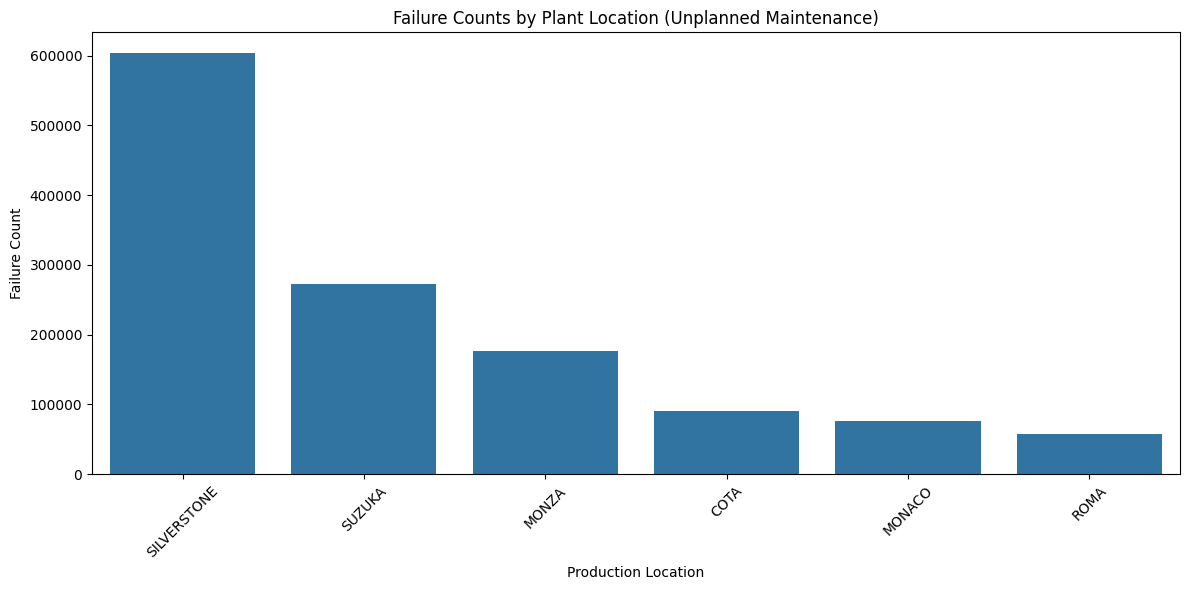

In [18]:
# Filter to include only unplanned maintenance cases (create a copy)
group_1_unplanned = group_1_df[group_1_df['MAINTENANCE_ACTIVITY_TYPE'] == 'Unplanned'].copy()

# Ensure 'PLANT_ID' and 'PRODUCTION_LOCATION' are correctly formatted
group_1_unplanned['PLANT_ID'] = group_1_unplanned['PLANT_ID'].astype(str)
group_1_unplanned['PRODUCTION_LOCATION'] = group_1_unplanned['PRODUCTION_LOCATION'].astype(str)

# Count the number of failures per plant
location_failures = group_1_unplanned.groupby(['PLANT_ID', 'PRODUCTION_LOCATION']).size().reset_index(name='Failure_Count')

# Sort by Failure_Count in descending order
location_failures = location_failures.sort_values(by='Failure_Count', ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='PRODUCTION_LOCATION', y='Failure_Count', data=location_failures)
plt.title('Failure Counts by Plant Location (Unplanned Maintenance)')
plt.xlabel('Production Location')
plt.ylabel('Failure Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Summary of Output:

The bar chart displays the failure counts by plant location for unplanned maintenance events. It indicates that:

- **SILVERSTONE** has the highest number of failures, significantly exceeding the other locations, with a count of over 600,000. This suggests that SILVERSTONE may have issues leading to frequent unplanned maintenance, requiring focused attention.
- **SUZUKA** and **MONZA** have the second and third highest failure counts, respectively, with SUZUKA around 300,000 and MONZA slightly lower.
- **COTA**, **MONACO**, and **ROMA** have much lower failure counts compared to SILVERSTONE, with counts ranging between 50,000 to 150,000.

This pattern suggests that the SILVERSTONE plant may be facing more challenges related to maintenance, leading to more frequent failures, while the other locations have relatively fewer unplanned maintenance issues.

### "FUNCTIONAL_LOC"


The first field to store Meta-data related to any production interruptions is the "FUNCTIONAL_LOC" column. This column is a sort of smart serial number that allows failures or interruptions to be stored as a smart identification number representing: plant – process – sub process – product line – machine.

If this number is present in the IWC work order, we should have identifiable information of which, plant process, or product line experienced the failure.

In [19]:
group_1_df.groupby('FUNCTIONAL_LOC').size().sort_values(ascending=False)

,0
FUNCTIONAL_LOC,
G812-PRD,5923
G812-PRD-A25,4930
G816-PRD-L15-L03-L080,4583
G816-PRD-L15-L01-L080,4401
G816-PRD-L30-L02-L080,4080
...,...
G291-PRD-L30-L01-L090,1
G291-PRD-L15-L04-L230,1
G811-PRD-L30-L03-L030-0060,1


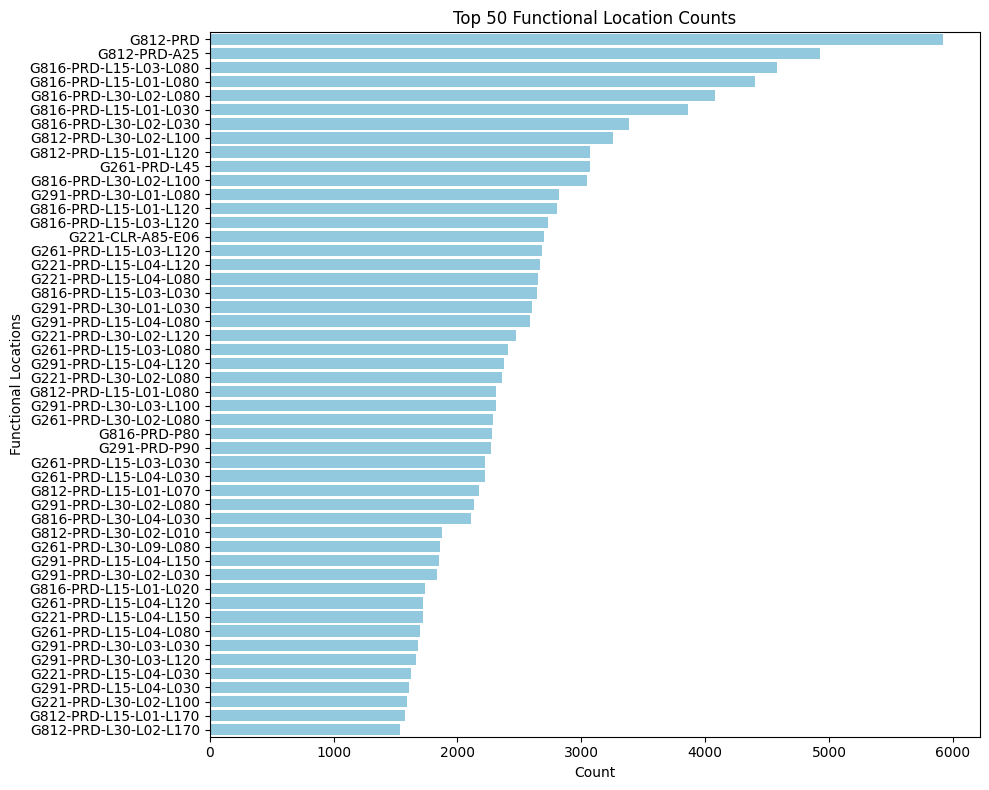

In [20]:
# Analyze FUNCTIONAL_LOC and include only the top 50 by total count
funct_loc = group_1_df.groupby('FUNCTIONAL_LOC').size().sort_values(ascending=False).head(50)

# Plotting the top 50 FUNCTIONAL_LOC by count
plt.figure(figsize=(10, 8))
sns.barplot(x=funct_loc.values, y=funct_loc.index, color='skyblue')
plt.title('Top 50 Functional Location Counts')
plt.xlabel('Count')
plt.ylabel('Functional Locations')
plt.tight_layout()
plt.show()


In [21]:
# Filter out rows where 'FUNCTIONAL_LOC' has missing data
df_loc = group_1_df[group_1_df['FUNCTIONAL_LOC'].notna()]

# Group by 'PRODUCTION_LOCATION' and 'FUNCTIONAL_AREA_NODE_1_MODIFIED', and count the size
result = df_loc .groupby(['PRODUCTION_LOCATION']).size()

# Sort by the size of the groups in descending order and return the top 15
result_sorted = result.sort_values(ascending=False)

result_sorted

,0
PRODUCTION_LOCATION,
COTA,70188
SILVERSTONE,62625
MONZA,58343
ROMA,41183
SUZUKA,39412
MONACO,20031


In [22]:
# Group by 'PRODUCTION_LOCATION' and 'FUNCTIONAL_AREA_NODE_1_MODIFIED', and count the size. Sort by the size of the groups in descending order and return the top 15
loc_Top_Prod = df_loc.groupby(['PRODUCTION_LOCATION', 'FUNCTIONAL_LOC']).size().sort_values(ascending=False)

loc_Top_Prod.head(30)

PRODUCTION_LOCATION  FUNCTIONAL_LOC       
ROMA                 G812-PRD                 5923
                     G812-PRD-A25             4930
COTA                 G816-PRD-L15-L03-L080    4583
                     G816-PRD-L15-L01-L080    4401
                     G816-PRD-L30-L02-L080    4080
                     G816-PRD-L15-L01-L030    3858
                     G816-PRD-L30-L02-L030    3388
ROMA                 G812-PRD-L30-L02-L100    3255
                     G812-PRD-L15-L01-L120    3074
SILVERSTONE          G261-PRD-L45             3069
COTA                 G816-PRD-L30-L02-L100    3049
MONZA                G291-PRD-L30-L01-L080    2822
COTA                 G816-PRD-L15-L01-L120    2805
                     G816-PRD-L15-L03-L120    2733
SUZUKA               G221-CLR-A85-E06         2699
SILVERSTONE          G261-PRD-L15-L03-L120    2682
SUZUKA               G221-PRD-L15-L04-L120    2668
                     G221-PRD-L15-L04-L080    2647
COTA                 G816-PRD-L15-L03-L030    2646
MONZA                G291-PRD-L30-L01-L030    2603
                     G291-PRD-L15-L04-L080    2589
SUZUKA               G221-PRD-L30-L02-L120    2470
SILVERSTONE          G261-PRD-L15-L03-L080    2406
MONZA                G291-PRD-L15-L04-L120    2379
SUZUKA               G221-PRD-L30-L02-L080    2359
MONZA                G291-PRD-L30-L03-L100    2311
ROMA                 G812-PRD-L15-L01-L080    2311
SILVERSTONE          G261-PRD-L30-L02-L080    2283
COTA                 G816-PRD-P80             2277
MONZA                G291-PRD-P90             2267
dtype: int64

### "FUNCTIONAL_AREA_NODE_1_MODIFIED"

The second Meta-data field is  "FUNCTIONAL_AREA_NODE_1_MODIFIED". This column stores more details about the functional area within the plant

As can be seen from the count of entries, there are less ofthese details in the IWC work orders than the "FUNCTIONAL_LOC"  field. This data set is still representative of failures occurring in each of the 5 plants. We can see that COTA PRODUCTION has the most failures with 70,187 occurring in this class.

In [23]:
group_1_df.groupby('FUNCTIONAL_AREA_NODE_1_MODIFIED').size().sort_values(ascending=False)

,0
FUNCTIONAL_AREA_NODE_1_MODIFIED,
COTA PRODUCTION,70187
SILVERSTONE PRODUCTION,62625
PRODUCTION,60312
MONZA PRODUCTION,57458
SUZUKA PRODUCTION,36713
COOLER SERVICE,2699
FLEET,123


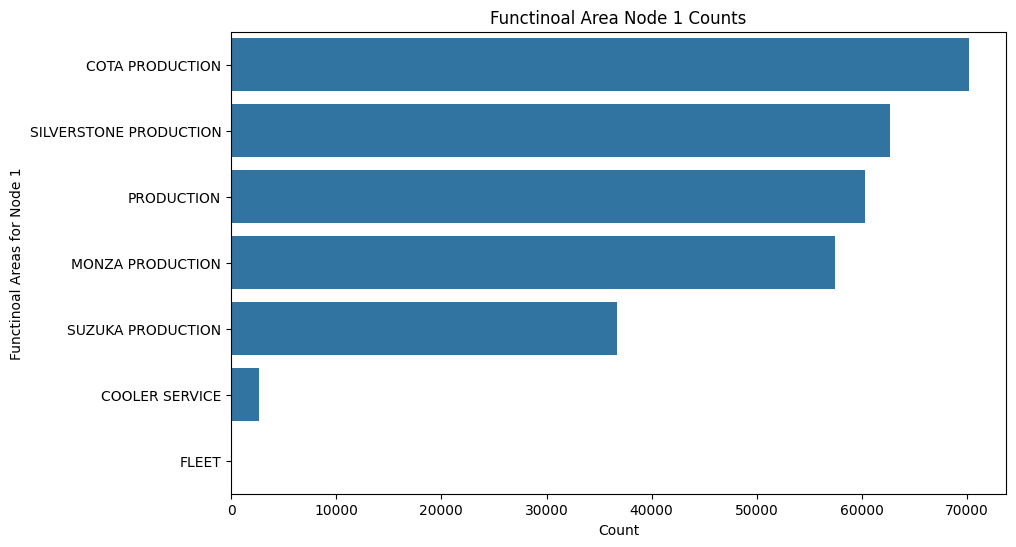

In [24]:
# Analyze FUNCTIONAL_AREA_NODE_1_MODIFIED
funct_area_1 = group_1_df.groupby('FUNCTIONAL_AREA_NODE_1_MODIFIED').size().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=funct_area_1.values, y=funct_area_1.index)
plt.title('Functinoal Area Node 1 Counts')
plt.xlabel('Count')
plt.ylabel('Functinoal Areas for Node 1')
plt.show()

In [25]:
# Filter out rows where 'FUNCTIONAL_AREA_NODE_1_MODIFIED' has missing data
df_FA1 = group_1_df[group_1_df['FUNCTIONAL_AREA_NODE_1_MODIFIED'].notna()]

# Group by 'PRODUCTION_LOCATION' and 'FUNCTIONAL_AREA_NODE_1_MODIFIED', and count the size
result = df_FA1 .groupby(['PRODUCTION_LOCATION']).size()

# Sort by the size of the groups in descending order and return the top 15
result_sorted = result.sort_values(ascending=False)

result_sorted

,0
PRODUCTION_LOCATION,
COTA,70188
SILVERSTONE,62625
MONZA,57458
ROMA,41183
SUZUKA,39412
MONACO,19251


In [26]:
# Group by 'PRODUCTION_LOCATION' and 'FUNCTIONAL_AREA_NODE_1_MODIFIED', and count the size. Sort by the size of the groups in descending order and return the top 15
FA1_Top_Prod_Loc = df_FA1.groupby(['PRODUCTION_LOCATION', 'FUNCTIONAL_AREA_NODE_1_MODIFIED']).size().sort_values(ascending=False)

FA1_Top_Prod_Loc.head(30)

,,0
PRODUCTION_LOCATION,FUNCTIONAL_AREA_NODE_1_MODIFIED,
COTA,COTA PRODUCTION,70187
SILVERSTONE,SILVERSTONE PRODUCTION,62625
MONZA,MONZA PRODUCTION,57458
ROMA,PRODUCTION,41061
SUZUKA,SUZUKA PRODUCTION,36713
MONACO,PRODUCTION,19251
SUZUKA,COOLER SERVICE,2699
ROMA,FLEET,122
COTA,FLEET,1


### "FUNCTIONAL_AREA_NODE_2_MODIFIED"

"FUNCTIONAL_AREA_NODE_2_MODIFIED" is a column that stores more details about the region-based subset inside of the functional area within the plant

We can see that the can line has the most recorded Work orders in this class but when we group this with location, we can see that this is mostly at the Cota facility. The Monza facility has problems with the bottle line and the Silverstone facility has issues with 1,2,and 9 BOTTLE LINES.




In [27]:
group_1_df.groupby('FUNCTIONAL_AREA_NODE_2_MODIFIED').size().sort_values(ascending=False).head(15)

,0
FUNCTIONAL_AREA_NODE_2_MODIFIED,
CAN LINE,34208
BTL_PET_LINE,32789
"LINES 1,2,9 - BOTTLE LINES",29729
BOTTLE LINE,27543
"LINES 3,4,10 - CAN LINES",23153
"L1, L2, L6 PET BOTTLE LINES",22460
G812 PRD FILLER_ROTARY_CAN,17390
ROTARY_CAN_LINE,14016
G812 PRD FILLER_ROT_BTL_PET,11200


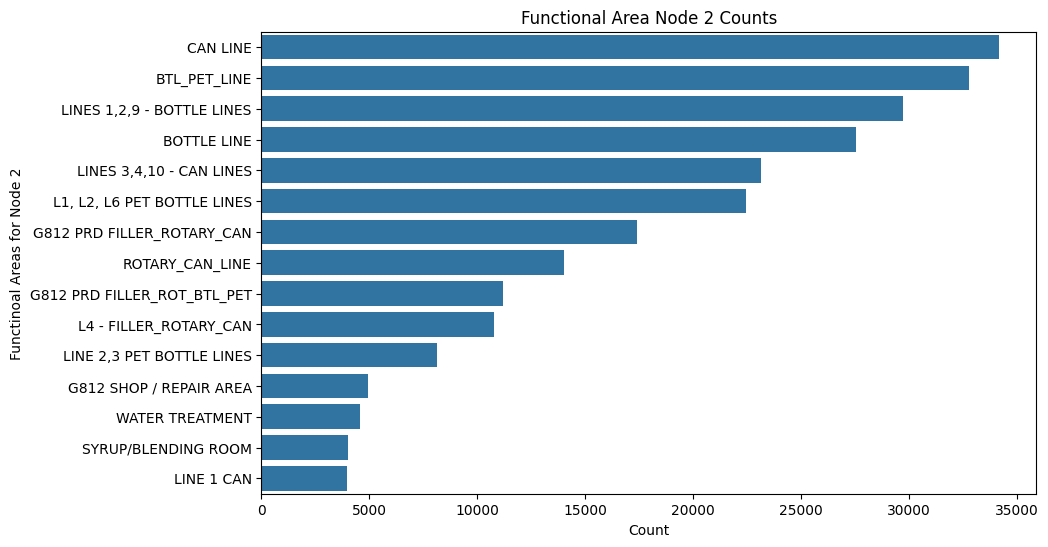

In [28]:
# Analyze FUNCTIONAL_AREA_NODE_2_MODIFIED
funct_area_2 = group_1_df.groupby('FUNCTIONAL_AREA_NODE_2_MODIFIED').size().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=funct_area_2.values, y=funct_area_2.index)
plt.title('Functional Area Node 2 Counts')
plt.xlabel('Count')
plt.ylabel('Functinoal Areas for Node 2')
plt.show()

In [29]:
# Filter out rows where 'FUNCTIONAL_AREA_NODE_2_MODIFIED' has missing data
df_FA2 = group_1_df[group_1_df['FUNCTIONAL_AREA_NODE_2_MODIFIED'].notna()]

# Group by 'PRODUCTION_LOCATION' and 'FUNCTIONAL_AREA_NODE_2_MODIFIED', and count the size
result = df_FA2 .groupby(['PRODUCTION_LOCATION']).size()

# Sort by the size of the groups in descending order and return the top 15
result_sorted = result.sort_values(ascending=False)

result_sorted

,0
PRODUCTION_LOCATION,
COTA,68972
SILVERSTONE,62625
MONZA,56979
SUZUKA,39348
ROMA,35260
MONACO,19223


In [30]:
# Group by 'PRODUCTION_LOCATION' and 'FUNCTIONAL_AREA_NODE_2_MODIFIED', and count the size. Sort by the size of the groups in descending order and return the top 15
FA2_Top_Prod_Loc = df_FA2.groupby(['PRODUCTION_LOCATION', 'FUNCTIONAL_AREA_NODE_2_MODIFIED']).size().sort_values(ascending=False)

FA2_Top_Prod_Loc.head(30)

,,0
PRODUCTION_LOCATION,FUNCTIONAL_AREA_NODE_2_MODIFIED,
COTA,CAN LINE,34208
MONZA,BTL_PET_LINE,32789
SILVERSTONE,"LINES 1,2,9 - BOTTLE LINES",29729
COTA,BOTTLE LINE,27543
SILVERSTONE,"LINES 3,4,10 - CAN LINES",23153
SUZUKA,"L1, L2, L6 PET BOTTLE LINES",22460
ROMA,G812 PRD FILLER_ROTARY_CAN,17390
MONZA,ROTARY_CAN_LINE,14016
ROMA,G812 PRD FILLER_ROT_BTL_PET,11200


### FUNCTIONAL_AREA_NODE_3_MODIFIED

Cota frequently experiences issues with "CAN_LINE" and "BOTTLE_LINE_PET," particularly in Lines #1, #2, and #3.

Monza shows the most work orders for "FILLER_ROTARY_CAN" and "FILLER_ROT_BTL_PET" lines, indicating bottle filling is a significant area of concern.

Silverstone has recurring issues in "FILLER_ROTARY_CAN" and "ROT_BTL_PET" lines, suggesting problems across several production lines.

In [31]:
group_1_df.groupby('FUNCTIONAL_AREA_NODE_3_MODIFIED').size().sort_values(ascending=False).head(15)

,0
FUNCTIONAL_AREA_NODE_3_MODIFIED,
LINE #4-FILLER_ROTARY_CAN,35834
LINE #2 - FILLER_ROT_BTL_PET,23027
LINE #1 - FILLER_ROT_BTL_PET,18290
LINE #1-CAN_LINE,17844
LINE #2 - BOTTLE_LINE_PET,17774
LINE #3-CAN_LINE,16364
G812 PRD FILLER_ROTARY_CAN LINE 1,12984
LINE #3-FILLER_ROTARY_CAN,12013
G812 PRD FILLER_ROT_BTL_PET LINE 2,11200


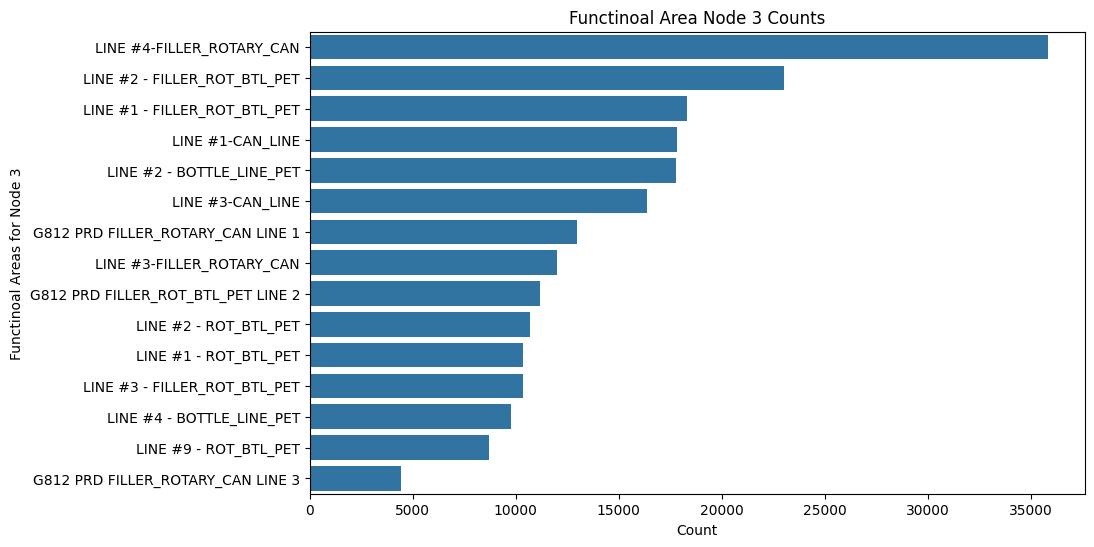

In [32]:
# Analyze FUNCTIONAL_AREA_NODE_3_MODIFIED
funct_area_3 = group_1_df.groupby('FUNCTIONAL_AREA_NODE_3_MODIFIED').size().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=funct_area_3.values, y=funct_area_3.index)
plt.title('Functinoal Area Node 3 Counts')
plt.xlabel('Count')
plt.ylabel('Functinoal Areas for Node 3')
plt.show()

In [33]:
# Filter out rows where 'FUNCTIONAL_AREA_NODE_3_MODIFIED' has missing data
df_FA3 = group_1_df[group_1_df['FUNCTIONAL_AREA_NODE_4_MODIFIED'].notna()]

# Group by 'PRODUCTION_LOCATION' and 'FUNCTIONAL_AREA_NODE_3_MODIFIED', and count the size
result = df_FA3 .groupby(['PRODUCTION_LOCATION']).size()

# Sort by the size of the groups in descending order and return the top 15
result_sorted = result.sort_values(ascending=False).head(15)

result_sorted

,0
PRODUCTION_LOCATION,
COTA,60813
SILVERSTONE,54096
MONZA,46713
SUZUKA,32355
ROMA,28932
MONACO,14664


In [34]:
# Group by 'PRODUCTION_LOCATION' and 'FUNCTIONAL_AREA_NODE_3_MODIFIED', and count the size. Sort by the size of the groups in descending order and return the top 15
FA3_Top_Prod_Loc = df_FA3.groupby(['PRODUCTION_LOCATION', 'FUNCTIONAL_AREA_NODE_3_MODIFIED']).size().sort_values(ascending=False).head(30)

FA3_Top_Prod_Loc

PRODUCTION_LOCATION  FUNCTIONAL_AREA_NODE_3_MODIFIED   
COTA                 LINE #1-CAN_LINE                      17407
                     LINE #2 - BOTTLE_LINE_PET             17299
                     LINE #3-CAN_LINE                      15974
MONZA                LINE #4-FILLER_ROTARY_CAN             13716
SUZUKA               LINE #2 - FILLER_ROT_BTL_PET          13192
ROMA                 G812 PRD FILLER_ROTARY_CAN LINE 1     12984
MONZA                LINE #1 - FILLER_ROT_BTL_PET          12471
SILVERSTONE          LINE #3-FILLER_ROTARY_CAN             11769
ROMA                 G812 PRD FILLER_ROT_BTL_PET LINE 2    11200
SILVERSTONE          LINE #4-FILLER_ROTARY_CAN             10832
SUZUKA               LINE #4-FILLER_ROTARY_CAN             10537
SILVERSTONE          LINE #2 - ROT_BTL_PET                 10274
                     LINE #1 - ROT_BTL_PET                  9943
MONZA                LINE #3 - FILLER_ROT_BTL_PET           9595
                     LINE #2 - FILLER_ROT_BTL_PET           9223
COTA                 LINE #4 - BOTTLE_LINE_PET              8638
SILVERSTONE          LINE #9 - ROT_BTL_PET                  8292
SUZUKA               LINE #1 - FILLER_ROT_BTL_PET           4886
ROMA                 G812 PRD FILLER_ROTARY_CAN LINE 3      4406
MONACO               LINE 3 SMALL PET                       4047
                     LINE 2 LARGET PET                      3939
                     LINE 1 CAN                             3938
SUZUKA               LINE #6-FILLER_ROTARY_BTL_PET          3529
SILVERSTONE          RECYCLING                              1350
                     LINE #8 - FILLER_BIB                   1163
MONZA                AIR SYSTEMS                            1035
MONACO               G811 STEAM SYSTEMS                      760
COTA                 SYRUP/BLENDING ROOM                     756
MONACO               G811 REFRIGERATION                      755
                     G811 CO2                                629
dtype: int64

### FUNCTIONAL_AREA_NODE_4_MODIFIED

Cota experiences the most work orders related to the "FILLER" area, with substantial issues in "CONVEYOR" and "PACKER" systems as well.

Silverstone has a similar pattern, with "FILLER" and "PACKER" being the most problematic, followed by "CONVEYOR" and "PALLETIZER."

Monza shows frequent issues in "FILLER," "CONVEYOR," and "PACKER" areas, alongside work orders for "LABELER" and "DEPALLETIZER."

In [35]:
group_1_df.groupby('FUNCTIONAL_AREA_NODE_4_MODIFIED').size().sort_values(ascending=False).head(15)

,0
FUNCTIONAL_AREA_NODE_4_MODIFIED,
FILLER,46322
PACKER,35230
CONVEYOR,34765
LABELER,18945
PALLETIZER,16239
DEPALLETIZER,10850
"DETECTOR, PRODUCT",9404
"SEAMER, ROTARY",8510
CAPPER,8350


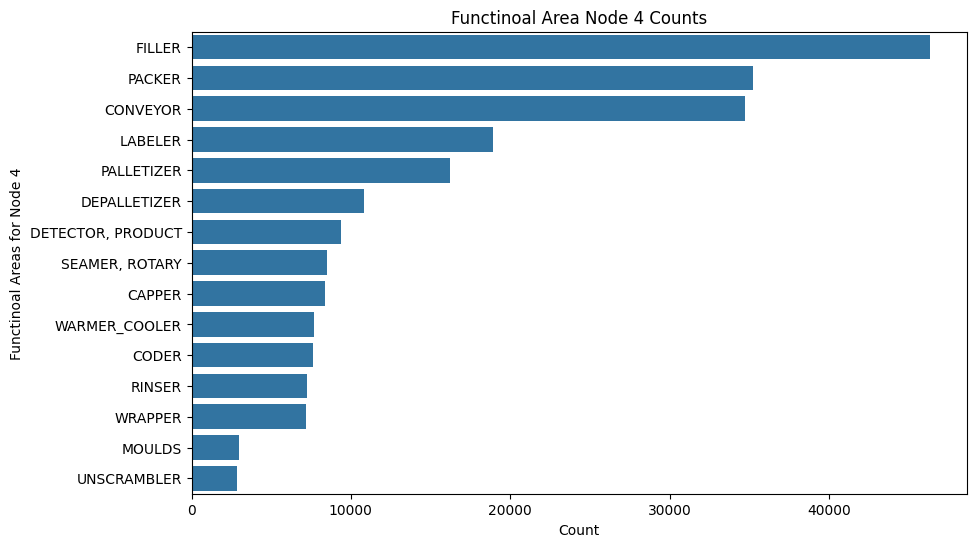

In [36]:
# Analyze FUNCTIONAL_AREA_NODE_4_MODIFIED
funct_area_4 = group_1_df.groupby('FUNCTIONAL_AREA_NODE_4_MODIFIED').size().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=funct_area_4.values, y=funct_area_4.index)
plt.title('Functinoal Area Node 4 Counts')
plt.xlabel('Count')
plt.ylabel('Functinoal Areas for Node 4')
plt.show()

In [37]:
# Filter out rows where 'FUNCTIONAL_AREA_NODE_4_MODIFIED' has missing data
df_FA4 = group_1_df[group_1_df['FUNCTIONAL_AREA_NODE_4_MODIFIED'].notna()]

# Group by 'PRODUCTION_LOCATION' and 'FUNCTIONAL_AREA_NODE_4_MODIFIED', and count the size
result = df_FA4 .groupby(['PRODUCTION_LOCATION']).size()

# Sort by the size of the groups in descending order and return the top 15
result_sorted = result.sort_values(ascending=False).head(15)

result_sorted

,0
PRODUCTION_LOCATION,
COTA,60813
SILVERSTONE,54096
MONZA,46713
SUZUKA,32355
ROMA,28932
MONACO,14664


In [38]:
# Group by 'PRODUCTION_LOCATION' and 'FUNCTIONAL_AREA_NODE_4_MODIFIED', and count the size. Sort by the size of the groups in descending order and return the top 15
FA4_Top_Prod_Loc = df_FA4.groupby(['PRODUCTION_LOCATION', 'FUNCTIONAL_AREA_NODE_4_MODIFIED']).size().sort_values(ascending=False).head(30)

FA4_Top_Prod_Loc


PRODUCTION_LOCATION  FUNCTIONAL_AREA_NODE_4_MODIFIED
COTA                 FILLER                             14261
                     CONVEYOR                           11999
SILVERSTONE          FILLER                              9710
MONZA                FILLER                              9049
COTA                 PACKER                              8428
SILVERSTONE          PACKER                              8287
                     CONVEYOR                            8160
MONZA                CONVEYOR                            7724
SUZUKA               PACKER                              6852
                     FILLER                              6269
MONZA                PACKER                              5391
ROMA                 FILLER                              4776
                     PACKER                              4657
MONZA                LABELER                             4429
SILVERSTONE          PALLETIZER                          4095
                     LABELER                             3832
COTA                 LABELER                             3820
                     PALLETIZER                          3817
SILVERSTONE          DETECTOR, PRODUCT                   3797
COTA                 CODER                               3760
ROMA                 WARMER_COOLER                       3258
                     LABELER                             3255
MONZA                DEPALLETIZER                        3033
                     RINSER                              2958
                     PALLETIZER                          2848
SUZUKA               CONVEYOR                            2759
SILVERSTONE          WRAPPER                             2506
SUZUKA               LABELER                             2482
SILVERSTONE          DEPALLETIZER                        2470
MONZA                CAPPER                              2457
dtype: int64

### "FUNCTIONAL_AREA_NODE_5_MODIFIED"

Failure data is available only for the Monaco, Monza, and Roma plants. The number of entries is very small compared to the other functional area nodes making this one of the least valuable fields.

In [39]:
group_1_df.groupby('FUNCTIONAL_AREA_NODE_5_MODIFIED').size().sort_values(ascending=False).head(15)

,0
FUNCTIONAL_AREA_NODE_5_MODIFIED,
FULL CAN TO ACCUMULATION TABLE,251
"PACKER 1, MODEL DUODOZEN 1250SX",210
FULL CASE CONVEYORS,158
EMPTY CASE CONVEYORS,136
FULL CASE SPIRAL TO PALLETIZER,125
FB CONVEYORS TO DOUGLAS/HI-CONE SPLIT,114
COMPRESSOR,110
EMPTY CAN,110
"PACKER 2, MODEL FENIX 185V",108


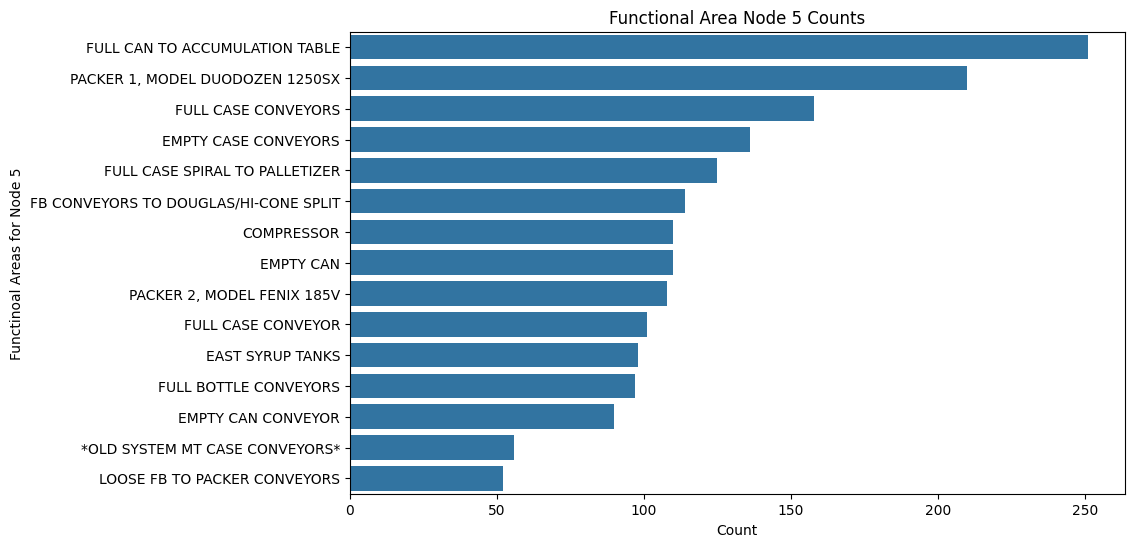

In [40]:
# Analyze FUNCTIONAL_AREA_NODE_5_MODIFIED
funct_area_5 = group_1_df.groupby('FUNCTIONAL_AREA_NODE_5_MODIFIED').size().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=funct_area_5.values, y=funct_area_5.index)
plt.title('Functional Area Node 5 Counts')
plt.xlabel('Count')
plt.ylabel('Functinoal Areas for Node 5')
plt.show()

In [41]:
# Filter out rows where 'FUNCTIONAL_AREA_NODE_5_MODIFIED' has missing data
df_FA5 = group_1_df[group_1_df['FUNCTIONAL_AREA_NODE_5_MODIFIED'].notna()]

# Group by 'PRODUCTION_LOCATION' and 'FUNCTIONAL_AREA_NODE_4_MODIFIED', and count the size
result = df_FA5 .groupby(['PRODUCTION_LOCATION']).size()

# Sort by the size of the groups in descending order and return the top 15
result_sorted = result.sort_values(ascending=False).head(15)

result_sorted

,0
PRODUCTION_LOCATION,
MONACO,1561
MONZA,371
ROMA,248


In [42]:
# Group by 'PRODUCTION_LOCATION' and 'FUNCTIONAL_AREA_NODE_4_MODIFIED', and count the size. Sort by the size of the groups in descending order and return the top 15
FA5_Top_Prod_Loc = df_FA5.groupby(['PRODUCTION_LOCATION', 'FUNCTIONAL_AREA_NODE_5_MODIFIED']).size().sort_values(ascending=False).head(30)

FA5_Top_Prod_Loc


PRODUCTION_LOCATION  FUNCTIONAL_AREA_NODE_5_MODIFIED         
MONACO               FULL CAN TO ACCUMULATION TABLE              251
MONZA                PACKER 1, MODEL DUODOZEN 1250SX             210
MONACO               FULL CASE CONVEYORS                         158
                     EMPTY CASE CONVEYORS                        136
                     FULL CASE SPIRAL TO PALLETIZER              125
                     FB CONVEYORS TO DOUGLAS/HI-CONE SPLIT       114
                     COMPRESSOR                                  110
                     EMPTY CAN                                   110
MONZA                PACKER 2, MODEL FENIX 185V                  108
ROMA                 FULL CASE CONVEYOR                          101
MONACO               EAST SYRUP TANKS                             98
                     FULL BOTTLE CONVEYORS                        97
ROMA                 EMPTY CAN CONVEYOR                           90
MONACO               *OLD SYSTEM MT CASE CONVEYORS*               56
                     LOOSE FB TO PACKER CONVEYORS                 52
ROMA                 FULL CAN CONVEYOR                            50
MONZA                EVANS COOLING TUNNEL L3, INSIDE BUILDING     48
MONACO               HARTNESS TO PAI FULL CASE CONVEYORS          47
                     PARTIAL CASES GPI (RIVERWOOD) TO DOUGLAS     43
                     INFEED TO HICONE TO PACKER                   33
                     EMPTY CAN VACUUM BLOWERS                     26
                     FULL CAN INFEED GPI                          24
                     DEPAL TO FILLER MT BOTTLE CONVEYORS          17
                     ACCUMULATION TABLES                          16
                     FULL CAN INFEED DOUGLAS/GPI (RIVERWOOD)      12
                     FULL CASE GPI (RIVERWOOD)                    10
                     FULL CASE FROM DOUGLAS TO PAI                 9
                     FULL CASE DOUGLAS                             7
ROMA                 PACK CONVEYOR                                 6
MONZA                EVANS COOLING TUNNEL L3, OUTSIDE BUILDIN      5
dtype: int64

## "EQUIPMENT ID"

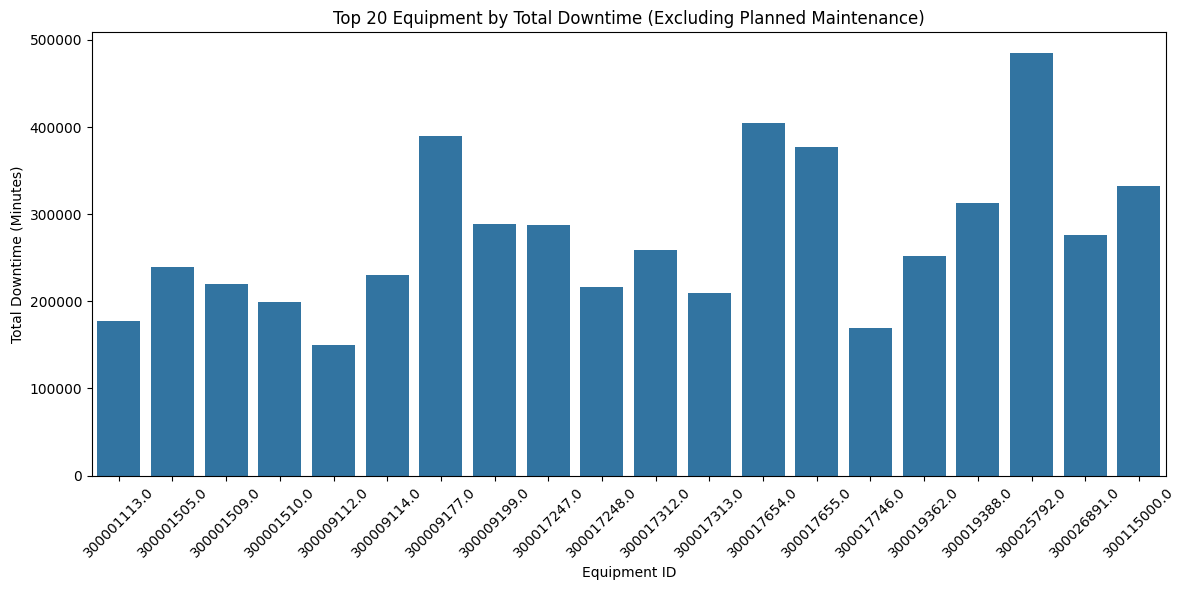

In [43]:
# Filter to exclude 'PLANNED' maintenance from the data
df_unplanned = group_1_df[group_1_df['MAINTENANCE_ACTIVITY_TYPE'] != 'PLANNED'].copy()

# Assuming that 'ACTUAL_WORK_IN_MINUTES' and 'EQUIPMENT_ID' are present in the DataFrame
# Total downtime per equipment (excluding 'PLANNED' maintenance)
equipment_downtime_total = df_unplanned.groupby('EQUIPMENT_ID')['ACTUAL_WORK_IN_MINUTES'].sum().reset_index()

# Get top 20 equipment with highest downtime
top_equipment_downtime = equipment_downtime_total.sort_values(by='ACTUAL_WORK_IN_MINUTES', ascending=False).head(20)

# Plotting with a cooler blue color
plt.figure(figsize=(12, 6))
sns.barplot(x='EQUIPMENT_ID', y='ACTUAL_WORK_IN_MINUTES', data=top_equipment_downtime, dodge=False, color='#1f77b4')  # A cooler blue
plt.title('Top 20 Equipment by Total Downtime (Excluding Planned Maintenance)')
plt.xlabel('Equipment ID')
plt.ylabel('Total Downtime (Minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- Equipment ID may be a good incicator of failure and preventitive maintenance against the target variable.
- Remeber that this helps identify which component within a larger machine (e.g., filler) the work was done on, such as a smaller component in the filler.

# Results

The data analysis reveals that only a subset of work orders provides detailed information across different functional area nodes, indicating that while there are over 1.4 million work orders in total, only a fraction includes granular failure data. Specifically:

291,782 entries have data for FUNCTIONAL_LOC, representing the total number of work orders tied to a specific functional location.

As we go from data node 1 down to 5 the number of entries decreases further.

The 291,782 entries with detailed "FUNCTIONAL_LOC" location data are what we will use to describe the failure modes inside each plant and will have to be what we base our predictive models on. The remaining entries lack the necessary metadata to gleen any information about lost productivity hours.

Our dataset, as shown above, is for large portions of the data is empty. A discussion before our modeling project will be had to first analyze our hypothesis and secondly understand important features in the model we eventually run. To combat the large portions of empty data we have chosen a strategy of dropping the values that go as unplanned maintenance to try to better understand how planned maintenance is performing. Dropping these rows will significantly enhance our dataset because it removes a large swath of largely empty rows that only skew our data in a negative direction.

In [44]:
!cp "/content/drive/MyDrive/Colab Notebooks/MSBA_FALL_EDA_MASTER.ipynb" ./
!jupyter nbconvert --to html "MSBA_FALL_EDA_MASTER.ipynb"

[NbConvertApp] Converting notebook MSBA_FALL_EDA_MASTER.ipynb to html
[NbConvertApp] Writing 696377 bytes to MSBA_FALL_EDA_MASTER.html
